# 02 · Early-enrichment benchmark

The paper's question is: given 40-300 activity labels from an initial screen, does using them help? This notebook benchmarks the label-using CPU baselines (LightGBM-ECFP, nearest-active similarity) against a structure-only reference, with the fine-tuned Boltz-2 (head-FT) column reserved. Nearest-active similarity is a comparator, not the paper's thesis.

Provisional and caveated: (1) one target only, and 588689 is the easiest of the eight (highest No-FT AP/EF, and per the SI the one where head-FT reduced unseen-scaffold recovery) - do not generalize from it; (2) the structure-only reference here is `score_boltz2`, which is the INITIAL Boltz-2 ranking, not the pipeline's No-FT rescore - head-FT will be compared to the pipeline No-FT, not to this proxy; (3) point estimates carry bootstrap CIs below because single runs on one target are not distinguishable from noise.

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 40)
ROOT = Path("/global/scratch/users/sergiomar10/boltzaff")
QC = pd.read_csv(ROOT / "results/runs/588689/qc.csv")
# all text black, normal weight (no bold)
BLK="#000000"; GRID="#dedede"
PALETTE=["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#4a3aa7","#e34948","#008300"]
ACTIVE="#1baf7a"; INACTIVE="#9aa0a6"; BLUE="#2a78d6"
mpl.rcParams.update({
  "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.6,"axes.axisbelow":True,
  "axes.spines.top":False,"axes.spines.right":False,"figure.dpi":100})
METRICS=["confidence","complex_plddt","ptm","iptm","ligand_iptm","complex_pde"]
print(f"folded compounds: {len(QC)}   actives: {int(QC.Active.sum())} ({QC.Active.mean()*100:.2f}%)")

from IPython.display import display
sys.path.insert(0, str(ROOT/"BoltzFT/evaluation"))
from metrics import all_metrics
CB = pd.read_csv(ROOT/"results/analysis/cpu_baselines_588689.csv")
print("methods:", sorted(CB.method.unique()))

folded compounds: 21061   actives: 238 (1.13%)


methods: ['Boltz2_noFT(score)', 'LightGBM_ECFP', 'LightGBM_ECFP_avg5', 'NearestActive_Tanimoto']


## The table: No-FT / LightGBM / nearest-active, head-FT reserved
All on the full common eval set (49,685 compounds, 396 actives). EF@1% is enrichment over random; AP and BEDROC weight the top of the ranking.

In [2]:
def rows_for(m,label):
    return [dict(method=label,N=int(r.n_train),AUROC=r.auroc,AP=r.auprc,EF1=r.ef_1pct,BEDROC=r.bedroc)
            for _,r in CB[CB.method==m].iterrows()]
T=rows_for("Boltz2_noFT(score)","Boltz-2 initial score (proxy)")
T+=rows_for("LightGBM_ECFP_avg5","LightGBM-ECFP")
T+=rows_for("NearestActive_Tanimoto","Nearest-active Tanimoto")
sp=ROOT/"results/analysis/588689/spread.csv"
hft_ready=sp.exists()
if hft_ready:
    s=pd.read_csv(sp)
    for _,r in s[s.n_train>0].iterrows():
        T.append(dict(method="Boltz-2 head-FT",N=int(r.n_train),AUROC=np.nan,
                      AP=r["ap_mean"],EF1=r["ef1_mean"],BEDROC=r["bedroc_mean"]))
else:
    for N in (40,100,300): T.append(dict(method="Boltz-2 head-FT",N=N,AUROC=np.nan,AP=np.nan,EF1=np.nan,BEDROC=np.nan))
tab=pd.DataFrame(T)
print("head-FT results present:", hft_ready)
order=["Boltz-2 initial score (proxy)","Nearest-active Tanimoto","LightGBM-ECFP","Boltz-2 head-FT"]
for metric in ["EF1","AP","BEDROC"]:
    piv=tab.pivot_table(index="method",columns="N",values=metric).reindex(order)
    print(f"\n{metric} by method x N (N=0 column is No-FT, structure-free):")
    display(piv.round(3))

head-FT results present: True

EF1 by method x N (N=0 column is No-FT, structure-free):


N,0,40,100,300
method,,,,
Boltz-2 initial score (proxy),18.429,NaN,NaN,NaN
Nearest-active Tanimoto,NaN,5.806,8.331,24.992
LightGBM-ECFP,NaN,3.534,7.826,11.613
Boltz-2 head-FT,NaN,22.784,25.093,32.313



AP by method x N (N=0 column is No-FT, structure-free):


N,0,40,100,300
method,,,,
Boltz-2 initial score (proxy),0.095,NaN,NaN,NaN
Nearest-active Tanimoto,NaN,0.020,0.043,0.166
LightGBM-ECFP,NaN,0.014,0.036,0.043
Boltz-2 head-FT,NaN,0.124,0.155,0.207



BEDROC by method x N (N=0 column is No-FT, structure-free):


N,0,40,100,300
method,,,,
Boltz-2 initial score (proxy),0.457,NaN,NaN,NaN
Nearest-active Tanimoto,NaN,0.144,0.203,0.367
LightGBM-ECFP,NaN,0.120,0.233,0.259
Boltz-2 head-FT,NaN,0.506,0.548,0.572


## Bootstrap 95% CIs (full eval)
The paper reports single runs; here every full-eval point estimate gets a 1000-sample bootstrap CI over the eval compounds. Overlapping CIs = the difference is not distinguishable from noise.

In [3]:
ci=pd.read_csv(ROOT/"results/analysis/cpu_ci_588689.csv")
lab={"Boltz2_initial_score":"Boltz-2 initial (proxy)","NearestActive_Tanimoto":"Nearest-active","LightGBM_ECFP_avg5":"LightGBM-ECFP"}
ci["method"]=ci.method.map(lab).fillna(ci.method)
ci["EF1_95CI"]=ci.apply(lambda r:f"[{r.ef1_lo:.1f}, {r.ef1_hi:.1f}]",axis=1)
ci["AP_95CI"]=ci.apply(lambda r:f"[{r.ap_lo:.3f}, {r.ap_hi:.3f}]",axis=1)
ci[["method","n_train","EF1_95CI","AP_95CI"]]

,method,n_train,EF1_95CI,AP_95CI
0,Boltz-2 initial (proxy),0,"[14.9, 22.2]","[0.078, 0.121]"
1,Nearest-active,40,"[3.6, 8.0]","[0.015, 0.032]"
2,LightGBM-ECFP,40,"[1.9, 5.6]","[0.012, 0.017]"
3,Nearest-active,100,"[5.8, 11.2]","[0.029, 0.065]"
4,LightGBM-ECFP,100,"[5.3, 10.4]","[0.028, 0.052]"
5,Nearest-active,300,"[21.0, 28.8]","[0.129, 0.207]"
6,LightGBM-ECFP,300,"[8.6, 14.6]","[0.032, 0.061]"


## EF@1% and average precision vs label budget
Dashed line = off-the-shelf Boltz-2 (No-FT), which uses no labels. The reserved slot is where the fine-tuned Boltz-2 arm will appear; its job is to clear the nearest-active similarity bar.

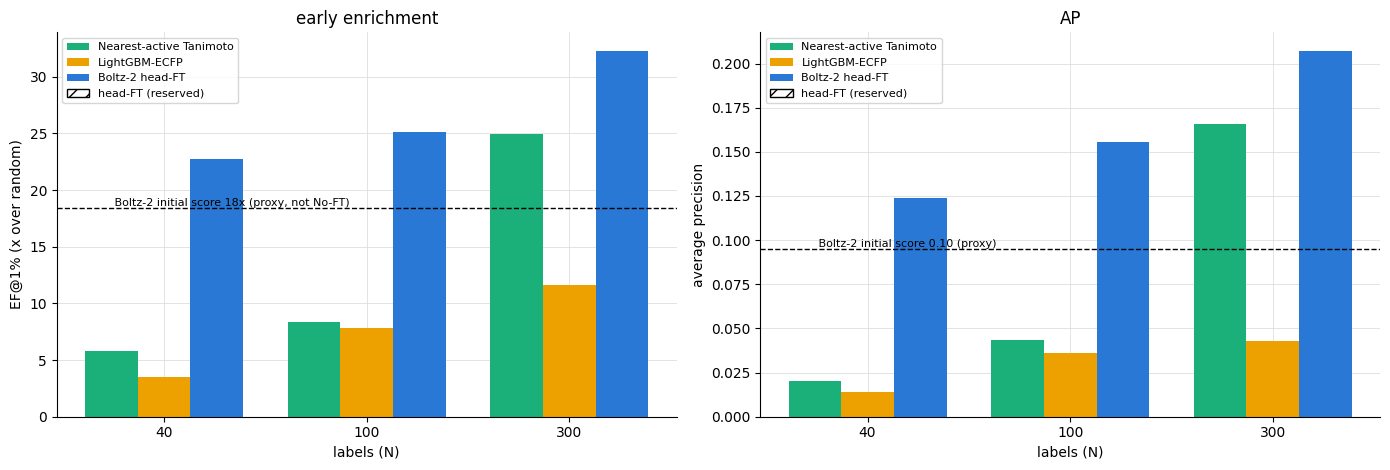

In [4]:
import matplotlib.patches as mpatches
Ns=[40,100,300]; methods=["Nearest-active Tanimoto","LightGBM-ECFP","Boltz-2 head-FT"]
cols={"Nearest-active Tanimoto":PALETTE[2],"LightGBM-ECFP":PALETTE[3],"Boltz-2 head-FT":BLUE}
def vals(mth,col):
    return [ (tab[(tab.method==mth)&(tab.N==n)][col].values[:1] or [np.nan])[0] for n in Ns]
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,4.8)); x=np.arange(len(Ns)); w=0.26
for i,mth in enumerate(methods):
    ef=vals(mth,"EF1"); ap=vals(mth,"AP")
    if mth=="Boltz-2 head-FT" and not hft_ready:
        for a in (a1,a2):
            for xi in x: a.text(xi+i*w, 0, " head-FT\n pending", ha="center", va="bottom", fontsize=7, rotation=90)
        continue
    a1.bar(x+i*w,ef,w,color=cols[mth],label=mth); a2.bar(x+i*w,ap,w,color=cols[mth],label=mth)
noft_ef=tab[tab.method=="Boltz-2 initial score (proxy)"].EF1.values[0]; noft_ap=tab[tab.method=="Boltz-2 initial score (proxy)"].AP.values[0]
a1.axhline(noft_ef,color=BLK,ls="--",lw=1); a2.axhline(noft_ap,color=BLK,ls="--",lw=1)
a1.text(0,noft_ef,f" Boltz-2 initial score {noft_ef:.0f}x (proxy, not No-FT)",va="bottom",fontsize=8)
a2.text(0,noft_ap,f" Boltz-2 initial score {noft_ap:.2f} (proxy)",va="bottom",fontsize=8)
resv=mpatches.Patch(facecolor="white",edgecolor=BLK,hatch="//",label="head-FT (reserved)")
for a,t,yl in [(a1,"EF@1% (x over random)","early enrichment"),(a2,"average precision","AP")]:
    a.set_xticks(x+w); a.set_xticklabels(Ns); a.set_xlabel("labels (N)"); a.set_ylabel(t); a.set_title(yl)
    h,l=a.get_legend_handles_labels(); a.legend(h+[resv],l+["head-FT (reserved)"],fontsize=8)
plt.tight_layout(); plt.show()

## LightGBM seed spread (subsampling on)
With row/feature subsampling the 5 seeds are genuinely independent, so this is the real within-condition spread of the descriptor baseline.

In [5]:
lg=CB[(CB.method=="LightGBM_ECFP")&(CB.seed>=0)]
lg.groupby("n_train")[["auprc","ef_1pct","bedroc"]].agg(["mean","std"]).round(4)

auprc          ef_1pct          bedroc        
           mean     std     mean     std    mean     std
n_train                                                 
40       0.0140  0.0012   2.9789  1.4325  0.1187  0.0121
100      0.0358  0.0023   7.7754  0.5757  0.2318  0.0082
300      0.0430  0.0016  11.4612  0.6583  0.2586  0.0032

## Memorization controls
Before trusting the enrichment numbers, three checks that decide whether they are real signal or leakage / analog bias.

### 1. Disjointness (no leakage)
The <=300 fine-tuning labels must not appear in the 49,685-compound eval set.

In [6]:
import gzip
ids=[int(x.strip().removeprefix("588689_")) for x in gzip.open(ROOT/"BoltzFT/data/splits/588689.txt.gz","rt")]
rr=pd.read_csv(ROOT/"data/588689_results.csv").set_index("CID").loc[ids].reset_index()
train=set(rr.CID[:300]); ev=set(rr.CID[300:])
assert train & ev == set(), "LEAK: train/eval overlap"
print(f"train(top300)={len(train)}  eval(>300)={len(ev)}  overlap={len(train & ev)}  -> no leakage")

train(top300)=300  eval(>300)=49685  overlap=0  -> no leakage


### 2. Analog bias
Max Tanimoto (ECFP r2) from each held-out active to its nearest training active. If this mass sits high, the nearest-active baseline wins by recovering analogs rather than by generalizing.

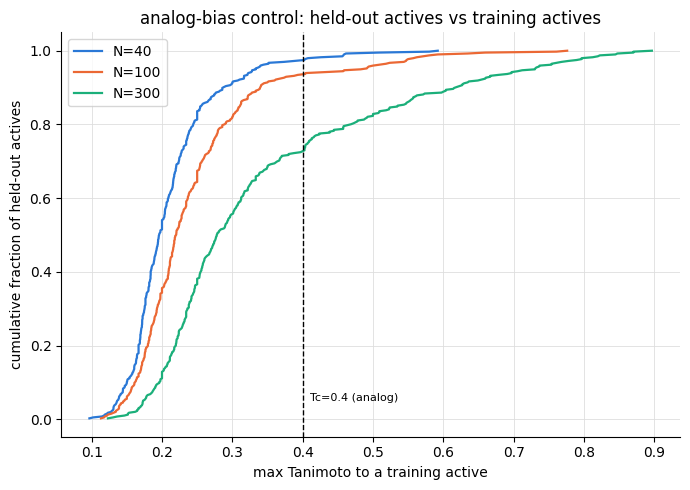

,median_maxTc,frac_gt_0p4,frac_gt_0p7,frac_share_scaffold
n_train,,,,
40,0.196,0.028,0.000,0.005
100,0.220,0.066,0.005,0.040
300,0.278,0.273,0.058,0.182


In [7]:
an=pd.read_csv(ROOT/"results/analysis/cpu_analog_588689.csv")
fig,ax=plt.subplots(figsize=(7,5))
for i,N in enumerate(sorted(an.n_train.unique())):
    v=np.sort(an[an.n_train==N].max_tc.values); cdf=np.arange(1,len(v)+1)/len(v)
    ax.plot(v,cdf,color=PALETTE[i],lw=1.6,label=f"N={N}")
ax.axvline(0.4,color=BLK,ls="--",lw=1); ax.text(0.41,0.05,"Tc=0.4 (analog)",fontsize=8)
ax.set_xlabel("max Tanimoto to a training active"); ax.set_ylabel("cumulative fraction of held-out actives")
ax.set_title("analog-bias control: held-out actives vs training actives"); ax.legend()
plt.tight_layout(); plt.show()
an.groupby("n_train").agg(median_maxTc=("max_tc","median"),
   frac_gt_0p4=("max_tc",lambda s:(s>0.4).mean()), frac_gt_0p7=("max_tc",lambda s:(s>0.7).mean()),
   frac_share_scaffold=("shares_active_scaffold","mean")).round(3)

### 3. Stratified recovery: analog bias, read correctly
Two things this does NOT show. It is not a fair No-FT-vs-labels test: the strata are defined by the 300 training labels, so a label-free method (the initial-score proxy) is near-flat across them almost by construction, and 81% of actives fall in the unseen stratum, so its stratum number approximates its full number by renormalization. And we do not use stratum-relative EF (that inflates the number by shrinking the base rate: full 0.80%, unseen 0.66%, low-sim 0.49%). Instead we count recovery from the COMPLETE-eval ranking (paper convention, ties by eval-ID order).

What it does show: the nearest-active baseline's enrichment is analog-driven. On the low-similarity stratum (max Tc < 0.3) it recovers essentially nothing. The fair test - head-FT vs nearest-active at matched N on these strata - is the reserved comparison the driver will fill.

In [8]:
ct=pd.read_csv(ROOT/"results/analysis/cpu_controls_588689.csv")
from IPython.display import display
lab={"Boltz2_initial_score":"Boltz-2 initial (proxy)","NearestActive_Tanimoto":"Nearest-active","LightGBM_ECFP_avg5":"LightGBM-ECFP"}
ct["method"]=ct.method.map(lab).fillna(ct.method)
N=300; c=ct[ct.n_train==N]
sizes=c.groupby("stratum")[["n","n_active","base_rate"]].first().round(4)
print(f"stratum sizes / base rates (N={N}):"); display(sizes)
piv=c.pivot_table(index="method",columns="stratum",values="rec_top1pct")
piv=piv[["full","unseen_scaffold","lowsim_lt0.3"]]
print("actives recovered in the GLOBAL top-1% (k=497), by stratum:"); display(piv.astype(int))

stratum sizes / base rates (N=300):


,n,n_active,base_rate
stratum,,,
full,49685,396,0.0080
lowsim_lt0.3,45338,220,0.0049
unseen_scaffold,48185,319,0.0066


actives recovered in the GLOBAL top-1% (k=497), by stratum:


stratum,full,unseen_scaffold,lowsim_lt0.3
method,,,
Boltz-2 initial (proxy),73,50,29
LightGBM-ECFP,46,12,3
Nearest-active,99,30,0


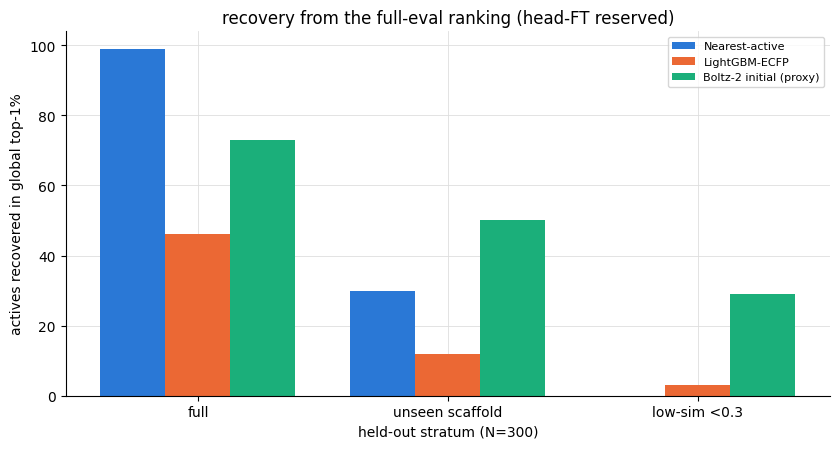

In [9]:
ms=[m for m in ["Nearest-active","LightGBM-ECFP","Boltz-2 initial (proxy)"] if m in set(c.method)]
strata=["full","unseen_scaffold","lowsim_lt0.3"]; x=np.arange(len(strata)); w=0.26
fig,ax=plt.subplots(figsize=(8.5,4.6))
for i,m in enumerate(ms):
    vals=[(c[(c.method==m)&(c.stratum==st)].rec_top1pct.values[:1] or [np.nan])[0] for st in strata]
    ax.bar(x+i*w,vals,w,color=PALETTE[i],label=m)
ax.set_xticks(x+w); ax.set_xticklabels(["full","unseen scaffold","low-sim <0.3"])
ax.set_ylabel("actives recovered in global top-1%"); ax.set_xlabel("held-out stratum (N=300)")
ax.set_title("recovery from the full-eval ranking (head-FT reserved)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Secondary (exploratory): confidence signals on the folded subset
Ranking the ~21k folded compounds by the structural-confidence metrics — these are not screening scores, and (as 01 showed) barely beat random. Kept here for contrast with the real scores. Note this uses the partial folded subset, a different population from the table above.

In [10]:
signals={"score_boltz2":1,"score_boltzina":1,"ligand_iptm":1,"confidence":1,"complex_plddt":1,
         "score_gnina":1,"score_vina":-1}
rows=[]
for name,sign in signals.items():
    if name not in QC or QC[name].notna().sum()<200: continue
    d=QC[[name,"Active"]].dropna()
    m=all_metrics(d.Active.values.astype(int), sign*d[name].values.astype(float))
    rows.append(dict(signal=name, n=len(d), AUROC=m["auroc"], AP=m["auprc"], EF_1pct=m["ef_1pct"], BEDROC=m["bedroc"]))
pd.DataFrame(rows).sort_values("AP",ascending=False).round(3).reset_index(drop=True)

,signal,n,AUROC,AP,EF_1pct,BEDROC
0,score_boltz2,21061,0.915,0.160,21.808,0.494
1,score_boltzina,21061,0.850,0.083,13.001,0.356
2,score_gnina,13033,0.615,0.021,5.897,0.152
3,ligand_iptm,21061,0.470,0.011,1.258,0.059
4,confidence,21061,0.408,0.010,2.097,0.049
5,complex_plddt,21061,0.380,0.009,1.258,0.040
6,score_vina,13033,0.363,0.008,0.000,0.032
